### Instituto Tecnológico y de Estudios Superiores de Monterrey. Campus en Línea
### Maestría en Inteligencia Artificial Aplicada
### Proyecto integrador (Gpo 10)
### Profesores titulares: Dra. Grettel Barceló Alonso &  Dr. Luis Eduardo Falcón Morales
### Profesora asistente: Mtra. Verónica Sandra Guzmán de Valle

### Equipo 22:
### Juan Felipe Toro Salgado A01794247
### Luis Fernando Caporal Montes de Oca A01795898
### Hugo Santiago Martínez Martínez A01283080
### Patrocinador: Ing. Pedro Eduardo González Rodríguez

### Proyecto: Mantenimiento proactivo basado en IA para hidroeléctricas 1–10 MW
### Avance 1. Análisis exploratorio de datos


In [ ]:
# Avance 1. Análisis exploratorio de datos

# Objetivos:
#  Elegir las características más relevantes para reducir la dimensionalidad y aumentar la capacidad de generalización del modelo.
#  Abordar y corregir los problemas identificados en los datos

# Carga de datos

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Mounted at /content/drive


In [ ]:
# El cliente final nos proporcionó, vía WhatsApp, dos archivos en Excel que contienen los datos medidos por su sistema SCADA durante un período determinado.
# Con esta información y la siguiente imagen, realizaremos nuestro análisis exploratorio de datos (EDA).

In [ ]:
df_1_link = "/content/drive/MyDrive/Proyecto Integrador - MNA Eq. 22/0. Información compartida /Data_Trend/Variables temperatura de G1 (parte 1).xlsx"
df_2_link = "/content/drive/MyDrive/Proyecto Integrador - MNA Eq. 22/0. Información compartida /Data_Trend/Variables de temperatura y vibraciones de G1 (parte 2).xlsx"

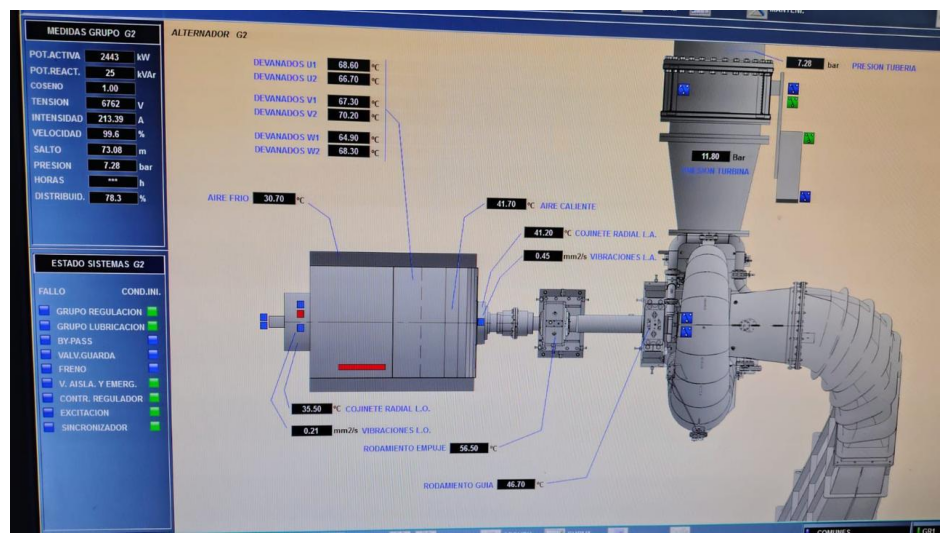

In [ ]:
# A continuación, se presenta una imagen que visualiza el sistema que vamos a medir.
link_imagen_central = '/content/drive/MyDrive/Proyecto Integrador - MNA Eq. 22/0. Información compartida /Fotografías Hidroeléctrica/SCADA_hidro.jpeg'
plt.figure(figsize=(12,19))
imagen_central = plt.imread(link_imagen_central)
plt.imshow(imagen_central)
plt.axis('off')
plt.show()

In [ ]:
# La imagen corresponde a una pantalla HMI/SCADA de monitoreo de un sistema turbina–generador (Grupo G2) utilizado para generación de energía eléctrica.

# Descripción del sistema
# Turbina: convierte la energía del fluido (aire/vapor/gas) en energía mecánica rotacional.
# Eje de acoplamiento: transmite el movimiento.
# Generador: convierte la energía mecánica en energía eléctrica.
# Rodamientos y cojinetes: soportan el eje y permiten su giro.
# Sistema de lubricación y enfriamiento.

In [ ]:
df_1 = pd.read_excel(df_1_link)
df_2 = pd.read_excel(df_2_link)

In [ ]:
df_1.head(3)

,FECHA,HORA,G1-TEMPERATURA DEVANADO U1 ValueY,G1-TEMPERATURA DEVANADO U2 ValueY,G1-TEMPERATURA DEVANADO V1 ValueY,G1-TEMPERATURA DEVANADO V2 ValueY,G1-TEMPERATURA DEVANADO W1 ValueY,G1-TEMPERATURA DEVANADO W2 ValueY,G1-TEMPERATURA AIRE CALIENTE ValueY,G1-TEMPERATURA AIRE FRIO ValueY
0,2026-01-12,00:00:08,61.700001,65.5,62.700001,61.799999,62.200001,60.799999,36.900002,25.200001
1,2026-01-12,00:00:18,61.700001,65.5,62.700001,61.799999,62.200001,60.799999,36.900002,25.200001
2,2026-01-12,00:00:28,61.700001,65.5,62.700001,61.799999,62.200001,60.799999,36.900002,25.100000


In [ ]:
df_2.head(3)

,FECHA,HORA,G1-TEMPERATURA COJINETE LA ValueY,G1-TEMPERATURA RODAMIENTO EMPUJE ValueY,G1-TEMPERATURA COJINETE RADIAL LO ValueY,G1-TEMPERATURA RODAMIENTO GUIA ValueY,G1-VIBRACION COJINETE LA ValueY,G1-VIBRACION COJINETE LO ValueY,G1-TEMPERATURA ACEITE GL ValueY,G1-TEMPERATURA ACEITE RODAMIENTO EMPUJE ValueY
0,2026-01-12,00:00:08,38.799999,56.900002,31.200001,49.700001,0.314497,0.299946,55.5,42.200001
1,2026-01-12,00:00:18,38.900002,56.900002,31.200001,49.700001,0.293751,0.317522,55.5,42.200001
2,2026-01-12,00:00:28,38.900002,56.900002,31.200001,49.700001,0.281650,0.332649,55.5,42.200001


In [ ]:
# Revisión del período de medición df_1
print("# Revisión del período de medición df_1")
print(f"El primer registro se realizó el día: {df_1[['FECHA','HORA']].iloc[0]}")
print(f"El último registro se realizó el día: {df_1[['FECHA','HORA']].iloc[138239]}")

# Revisión del período de medición df_1
El primer registro se realizó el día: FECHA    2026-01-12 00:00:00
HORA                00:00:08
Name: 0, dtype: object
El último registro se realizó el día: FECHA    2026-01-27 00:00:00
HORA                23:59:58
Name: 138239, dtype: object


In [ ]:
# Info df_1
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138240 entries, 0 to 138239
Data columns (total 10 columns):
 #   Column                               Non-Null Count   Dtype         
---  ------                               --------------   -----         
 0   FECHA                                138240 non-null  datetime64[ns]
 1   HORA                                 138240 non-null  object        
 2   G1-TEMPERATURA DEVANADO U1 ValueY    138240 non-null  float64       
 3   G1-TEMPERATURA DEVANADO U2 ValueY    138240 non-null  float64       
 4   G1-TEMPERATURA DEVANADO V1 ValueY    138240 non-null  float64       
 5   G1-TEMPERATURA DEVANADO V2 ValueY    138240 non-null  float64       
 6   G1-TEMPERATURA DEVANADO W1 ValueY    138240 non-null  float64       
 7   G1-TEMPERATURA DEVANADO W2 ValueY    138240 non-null  float64       
 8   G1-TEMPERATURA AIRE CALIENTE ValueY  138240 non-null  float64       
 9   G1-TEMPERATURA AIRE FRIO ValueY      138240 non-null  float64       
d

In [ ]:
# Revisión del período de medición df_2
print("Revisión del período de medición df_2")
print(f"El primer registro se realizó el día: {df_2[['FECHA','HORA']].iloc[0]}")
print(f"El último registro se realizó el día: {df_2[['FECHA','HORA']].iloc[138239]}")

Revisión del período de medición df_2
El primer registro se realizó el día: FECHA    2026-01-12 00:00:00
HORA                00:00:08
Name: 0, dtype: object
El último registro se realizó el día: FECHA    2026-01-27 00:00:00
HORA                23:59:58
Name: 138239, dtype: object


In [ ]:
# Info df_2
df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138240 entries, 0 to 138239
Data columns (total 10 columns):
 #   Column                                          Non-Null Count   Dtype         
---  ------                                          --------------   -----         
 0   FECHA                                           138240 non-null  datetime64[ns]
 1   HORA                                            138240 non-null  object        
 2   G1-TEMPERATURA COJINETE LA ValueY               138240 non-null  float64       
 3   G1-TEMPERATURA RODAMIENTO EMPUJE ValueY         138240 non-null  float64       
 4   G1-TEMPERATURA COJINETE RADIAL LO ValueY        138240 non-null  float64       
 5   G1-TEMPERATURA RODAMIENTO GUIA ValueY           138240 non-null  float64       
 6   G1-VIBRACION  COJINETE LA ValueY                138240 non-null  float64       
 7   G1-VIBRACION  COJINETE LO ValueY                138240 non-null  float64       
 8   G1-TEMPERATURA ACEITE GL ValueY   

In [ ]:
# Se analizaron las estampas de tiempo de ambos registros con el fin de verificar si correspondían al mismo periodo de medición.
# A partir de esta revisión, se confirma que los dos conjuntos de datos cubren el mismo rango temporal y se encuentran sincronizados,
# lo que indica que las mediciones fueron realizadas de manera paralela durante el mismo intervalo de tiempo.

# Unión de los dataframes

In [ ]:
# Crear una estampa de tiempo completa (FECHA + HORA)

# Convertir HORA a texto HH:MM:SS
hora_1 = pd.to_datetime(df_1['HORA'].astype(str), format='%H:%M:%S', errors='coerce').dt.strftime('%H:%M:%S')
hora_2 = pd.to_datetime(df_2['HORA'].astype(str), format='%H:%M:%S', errors='coerce').dt.strftime('%H:%M:%S')

# Crear TIMESTAMP (FECHA + HORA)
df_1['TIMESTAMP'] = pd.to_datetime(df_1['FECHA'].dt.strftime('%Y-%m-%d') + ' ' + hora_1, errors='coerce')
df_2['TIMESTAMP'] = pd.to_datetime(df_2['FECHA'].dt.strftime('%Y-%m-%d') + ' ' + hora_2, errors='coerce')

In [ ]:
# Confirmar alineación temporal (debe dar True)
print(df_1['TIMESTAMP'].equals(df_2['TIMESTAMP']))

True


In [ ]:
# Unión de los dos dataframes
data_trend = df_1.merge(
    df_2.drop(columns=['FECHA', 'HORA']),
    on='TIMESTAMP',
    how='inner'
)
data_trend =data_trend.set_index('TIMESTAMP')

In [ ]:
data_trend.head(3)

,FECHA,HORA,G1-TEMPERATURA DEVANADO U1 ValueY,G1-TEMPERATURA DEVANADO U2 ValueY,G1-TEMPERATURA DEVANADO V1 ValueY,G1-TEMPERATURA DEVANADO V2 ValueY,G1-TEMPERATURA DEVANADO W1 ValueY,G1-TEMPERATURA DEVANADO W2 ValueY,G1-TEMPERATURA AIRE CALIENTE ValueY,G1-TEMPERATURA AIRE FRIO ValueY,G1-TEMPERATURA COJINETE LA ValueY,G1-TEMPERATURA RODAMIENTO EMPUJE ValueY,G1-TEMPERATURA COJINETE RADIAL LO ValueY,G1-TEMPERATURA RODAMIENTO GUIA ValueY,G1-VIBRACION COJINETE LA ValueY,G1-VIBRACION COJINETE LO ValueY,G1-TEMPERATURA ACEITE GL ValueY,G1-TEMPERATURA ACEITE RODAMIENTO EMPUJE ValueY
TIMESTAMP,,,,,,,,,,,,,,,,,,
2026-01-12 00:00:08,2026-01-12,00:00:08,61.700001,65.5,62.700001,61.799999,62.200001,60.799999,36.900002,25.200001,38.799999,56.900002,31.200001,49.700001,0.314497,0.299946,55.5,42.200001
2026-01-12 00:00:18,2026-01-12,00:00:18,61.700001,65.5,62.700001,61.799999,62.200001,60.799999,36.900002,25.200001,38.900002,56.900002,31.200001,49.700001,0.293751,0.317522,55.5,42.200001
2026-01-12 00:00:28,2026-01-12,00:00:28,61.700001,65.5,62.700001,61.799999,62.200001,60.799999,36.900002,25.100000,38.900002,56.900002,31.200001,49.700001,0.281650,0.332649,55.5,42.200001


In [ ]:
data_trend.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 138240 entries, 2026-01-12 00:00:08 to 2026-01-27 23:59:58
Data columns (total 18 columns):
 #   Column                                          Non-Null Count   Dtype         
---  ------                                          --------------   -----         
 0   FECHA                                           138240 non-null  datetime64[ns]
 1   HORA                                            138240 non-null  object        
 2   G1-TEMPERATURA DEVANADO U1 ValueY               138240 non-null  float64       
 3   G1-TEMPERATURA DEVANADO U2 ValueY               138240 non-null  float64       
 4   G1-TEMPERATURA DEVANADO V1 ValueY               138240 non-null  float64       
 5   G1-TEMPERATURA DEVANADO V2 ValueY               138240 non-null  float64       
 6   G1-TEMPERATURA DEVANADO W1 ValueY               138240 non-null  float64       
 7   G1-TEMPERATURA DEVANADO W2 ValueY               138240 non-null  float64       
 8   

# Estructura de los datos

##### En esta sección se presenta una descripción general del conjunto de datos, incluyendo su dimensión, tipos de variables, estadísticas descriptivas, frecuencia de variables categóricas y la identificación de valores faltantes.


In [ ]:
# 1. Dimensión del dataset
print("Dimensiones (filas, columnas):",data_trend.shape)

Dimensiones (filas, columnas): (138240, 18)


In [ ]:
# 2. Información general y tipos de datos
data_trend.info()

# Esto muestra: Número de registros, Número de columnas, Tipos de datos y Valores nulos

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 138240 entries, 2026-01-12 00:00:08 to 2026-01-27 23:59:58
Data columns (total 18 columns):
 #   Column                                          Non-Null Count   Dtype         
---  ------                                          --------------   -----         
 0   FECHA                                           138240 non-null  datetime64[ns]
 1   HORA                                            138240 non-null  object        
 2   G1-TEMPERATURA DEVANADO U1 ValueY               138240 non-null  float64       
 3   G1-TEMPERATURA DEVANADO U2 ValueY               138240 non-null  float64       
 4   G1-TEMPERATURA DEVANADO V1 ValueY               138240 non-null  float64       
 5   G1-TEMPERATURA DEVANADO V2 ValueY               138240 non-null  float64       
 6   G1-TEMPERATURA DEVANADO W1 ValueY               138240 non-null  float64       
 7   G1-TEMPERATURA DEVANADO W2 ValueY               138240 non-null  float64       
 8   

In [ ]:
# 3. Vista rápida de los datos
data_trend.head(3) # Primeros 3 registros

,FECHA,HORA,G1-TEMPERATURA DEVANADO U1 ValueY,G1-TEMPERATURA DEVANADO U2 ValueY,G1-TEMPERATURA DEVANADO V1 ValueY,G1-TEMPERATURA DEVANADO V2 ValueY,G1-TEMPERATURA DEVANADO W1 ValueY,G1-TEMPERATURA DEVANADO W2 ValueY,G1-TEMPERATURA AIRE CALIENTE ValueY,G1-TEMPERATURA AIRE FRIO ValueY,G1-TEMPERATURA COJINETE LA ValueY,G1-TEMPERATURA RODAMIENTO EMPUJE ValueY,G1-TEMPERATURA COJINETE RADIAL LO ValueY,G1-TEMPERATURA RODAMIENTO GUIA ValueY,G1-VIBRACION COJINETE LA ValueY,G1-VIBRACION COJINETE LO ValueY,G1-TEMPERATURA ACEITE GL ValueY,G1-TEMPERATURA ACEITE RODAMIENTO EMPUJE ValueY
TIMESTAMP,,,,,,,,,,,,,,,,,,
2026-01-12 00:00:08,2026-01-12,00:00:08,61.700001,65.5,62.700001,61.799999,62.200001,60.799999,36.900002,25.200001,38.799999,56.900002,31.200001,49.700001,0.314497,0.299946,55.5,42.200001
2026-01-12 00:00:18,2026-01-12,00:00:18,61.700001,65.5,62.700001,61.799999,62.200001,60.799999,36.900002,25.200001,38.900002,56.900002,31.200001,49.700001,0.293751,0.317522,55.5,42.200001
2026-01-12 00:00:28,2026-01-12,00:00:28,61.700001,65.5,62.700001,61.799999,62.200001,60.799999,36.900002,25.100000,38.900002,56.900002,31.200001,49.700001,0.281650,0.332649,55.5,42.200001


In [ ]:
data_trend.tail(3) # Ultimos 3 registros

,FECHA,HORA,G1-TEMPERATURA DEVANADO U1 ValueY,G1-TEMPERATURA DEVANADO U2 ValueY,G1-TEMPERATURA DEVANADO V1 ValueY,G1-TEMPERATURA DEVANADO V2 ValueY,G1-TEMPERATURA DEVANADO W1 ValueY,G1-TEMPERATURA DEVANADO W2 ValueY,G1-TEMPERATURA AIRE CALIENTE ValueY,G1-TEMPERATURA AIRE FRIO ValueY,G1-TEMPERATURA COJINETE LA ValueY,G1-TEMPERATURA RODAMIENTO EMPUJE ValueY,G1-TEMPERATURA COJINETE RADIAL LO ValueY,G1-TEMPERATURA RODAMIENTO GUIA ValueY,G1-VIBRACION COJINETE LA ValueY,G1-VIBRACION COJINETE LO ValueY,G1-TEMPERATURA ACEITE GL ValueY,G1-TEMPERATURA ACEITE RODAMIENTO EMPUJE ValueY
TIMESTAMP,,,,,,,,,,,,,,,,,,
2026-01-27 23:59:38,2026-01-27,23:59:38,45.200001,47.700001,45.700001,45.400002,45.799999,44.400002,30.700001,22.5,33.200001,55.299999,28.700001,50.200001,0.289861,0.349649,55.0,41.799999
2026-01-27 23:59:48,2026-01-27,23:59:48,45.299999,47.700001,45.700001,45.500000,45.799999,44.400002,30.700001,22.5,33.200001,55.299999,28.700001,50.299999,0.304844,0.365784,55.0,41.799999
2026-01-27 23:59:58,2026-01-27,23:59:58,45.200001,47.700001,45.700001,45.400002,45.799999,44.400002,30.700001,22.5,33.200001,55.299999,28.700001,50.299999,0.310463,0.392148,55.0,41.799999


In [ ]:
# 4. Estadísticas descriptivas (variables numéricas)
data_trend.describe().T

,count,mean,min,25%,50%,75%,max,std
FECHA,138240,2026-01-19 11:59:59.999999744,2026-01-12 00:00:00,2026-01-15 18:00:00,2026-01-19 12:00:00,2026-01-23 06:00:00,2026-01-27 00:00:00,NaN
G1-TEMPERATURA DEVANADO U1 ValueY,138240.0,55.442348,38.900002,47.400002,57.700001,62.5,68.0,8.352761
G1-TEMPERATURA DEVANADO U2 ValueY,138240.0,58.691854,40.400002,49.799999,61.299999,66.400002,71.900002,9.014909
G1-TEMPERATURA DEVANADO V1 ValueY,138240.0,56.306823,39.599998,48.0,58.700001,63.5,69.300003,8.586055
G1-TEMPERATURA DEVANADO V2 ValueY,138240.0,55.441178,39.299999,47.400002,57.799999,62.599998,67.900002,8.341688
G1-TEMPERATURA DEVANADO W1 ValueY,138240.0,56.053989,39.900002,48.099998,58.200001,63.0,68.900002,8.308974
G1-TEMPERATURA DEVANADO W2 ValueY,138240.0,54.490661,38.700001,46.400002,56.799999,61.5,66.900002,8.289246
G1-TEMPERATURA AIRE CALIENTE ValueY,138240.0,34.29771,24.700001,31.5,34.599998,37.0,41.900002,3.851209
G1-TEMPERATURA AIRE FRIO ValueY,138240.0,24.463135,18.299999,22.4,24.299999,26.700001,38.700001,2.935855
G1-TEMPERATURA COJINETE LA ValueY,138240.0,35.983601,29.6,33.799999,36.099998,38.099998,42.700001,3.153004


In [ ]:
# 5. Valores faltantes
missing_values = data_trend.isnull().sum()
missing_values

,0
FECHA,0
HORA,0
G1-TEMPERATURA DEVANADO U1 ValueY,0
G1-TEMPERATURA DEVANADO U2 ValueY,0
G1-TEMPERATURA DEVANADO V1 ValueY,0
G1-TEMPERATURA DEVANADO V2 ValueY,0
G1-TEMPERATURA DEVANADO W1 ValueY,0
G1-TEMPERATURA DEVANADO W2 ValueY,0
G1-TEMPERATURA AIRE CALIENTE ValueY,0
G1-TEMPERATURA AIRE FRIO ValueY,0


In [ ]:
# 6. Detección rápida de duplicados
print("Registros duplicados:", data_trend.duplicated().sum())

Registros duplicados: 0


In [ ]:
# El conjunto de datos analizado cuenta con 138 240 registros y 18 variables, correspondientes a mediciones operativas del sistema turbina–generador.
# Las mediciones abarcan el período comprendido entre el 12 de enero de 2026 a las 00:00:08 y el 27 de enero de 2026 a las 23:59:58, con una frecuencia de muestreo aproximadamente constante cada 10 s.
# La mayoría de las variables corresponden a datos numéricos continuos (float64), asociados principalmente a temperaturas y niveles de vibración en distintos componentes del sistema.
# Adicionalmente, se incluyen variables temporales (fecha y hora), así como un índice temporal (`DatetimeIndex`) que facilita el análisis de series de tiempo.
# No se identificaron valores faltantes en ninguna de las variables del conjunto de datos, ni registros duplicados, lo que indica una adecuada calidad de los datos para continuar con análisis posteriores.
# En consecuencia, el conjunto de datos se considera completo, consistente y apto para la realización de análisis exploratorios más avanzados,
# tales como evaluación de tendencias temporales, análisis de correlación entre variables, detección de anomalías y estudios de comportamiento operativo del sistema.

# Funciones auxiliares

In [ ]:
def boxplot_grupo(df, cols, labels, titulo, ylabel):
    """
    Genera un boxplot con estadísticas (min, max, media y mediana)
    para un grupo de variables.

    Ejemplo:
    boxplot_grupo(data_trend, temp_devanados, temp_devanados_labels,
                  "Temperaturas de Devanados", "Temperatura [°C]")
    """

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.boxplot(
        df[cols].values,
        tick_labels=labels,
        patch_artist=True,
        showmeans=True,
        boxprops=dict(facecolor='lightsteelblue', edgecolor='black'),
        medianprops=dict(color='darkred', linewidth=2),
        whiskerprops=dict(color='black'),
        capprops=dict(color='black'),
        meanprops=dict(marker='^', markerfacecolor='green',
                       markeredgecolor='green', markersize=5),
        flierprops=dict(marker='o', markerfacecolor='gray',
                        alpha=0.5, markersize=3)
    )

    # Etiquetas estadísticas
    for i, col in enumerate(cols):
        s = df[col].dropna()
        x = i + 1

        ax.text(x, s.max(),    f"Max={s.max():.1f}", ha='center', va='bottom', fontsize=8)
        ax.text(x, s.min(),    f"Min={s.min():.1f}", ha='center', va='top',    fontsize=8)
        ax.text(x, s.median(), f"M={s.median():.1f}", ha='center', va='bottom',
                fontsize=8, color='darkred')
        ax.text(x, s.mean(),   f"μ={s.mean():.1f}", ha='center', va='bottom', fontsize=8)

    # Formato
    ax.set_title(f"Boxplot – {titulo}")
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
def histogramas_grupo(df, cols, labels, titulo, xlabel, bins=30):

    """
    Genera histogramas individuales para cada variable del grupo.

    Ejemplo:
    histogramas_grupo(data_trend, temp_devanados, temp_devanados_labels,
                      "Temperaturas de Devanados", "Temperatura [°C]")
    """

    n = len(cols)

    fig, ax = plt.subplots(1, n, figsize=(4*n, 4), squeeze=False)
    ax = ax.flatten()

    for i, col in enumerate(cols):

        s = df[col].dropna()

        ax[i].hist(s, bins=bins)
        ax[i].set_title(labels[i])
        ax[i].set_xlabel(xlabel)
        ax[i].set_ylabel("Frecuencia")
        ax[i].grid(alpha=0.3)

        # líneas estadísticas
        ax[i].axvline(s.mean(), linestyle='--', color='black', linewidth=2, label='Media')
        ax[i].axvline(s.median(), linestyle='-', color='red', linewidth=2, label='Mediana')

        ax[i].legend(fontsize=8)

    fig.suptitle(f"Histogramas – {titulo}")

    plt.tight_layout()
    plt.show()

In [ ]:
def tendencia_grupo_simple(df, cols, labels, titulo, ylabel, freq='1min'):
    """
    Grafica todas las variables del grupo en una sola figura.
    Se aplica remuestreo automático para simplificar la visualización.

    freq:
        '30s', '1min', '5min', etc.
    """

    # Remuestreo para simplificar (promedio temporal)
    df_res = df[cols].resample(freq).mean()

    plt.figure(figsize=(12,5))

    for col, label in zip(cols, labels):
        plt.plot(df_res.index, df_res[col], label=label, linewidth=1.5)

    plt.title(f"Tendencia temporal – {titulo}")
    plt.ylabel(ylabel)
    plt.xlabel("Tiempo")
    plt.grid(alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

# Análisis univariante
###### En esta sección se analiza cada variable de forma individual con el fin de comprender su distribución, tendencia central, dispersión y posibles valores atípicos.
##### Se emplean histogramas, diagramas de caja (boxplots) y gráficos de barras según el tipo de variable.

In [ ]:
# Con fines de organización del análisis, las variables se clasificarán por componente o subsistema de la central hidroeléctrica, facilitando su estudio individual.
# Variables a analizar por sub-grupos
# Agrupación de variables por subsistema
# Para facilitar el análisis exploratorio, las variables se agrupan según el componente o subsistema de la central hidroeléctrica al que pertenecen.
# Esta clasificación permite evaluar de forma independiente el comportamiento térmico, mecánico y de lubricación del conjunto turbina–generador.
data_trend.columns

Index(['FECHA', 'HORA', 'G1-TEMPERATURA DEVANADO U1 ValueY',
       'G1-TEMPERATURA DEVANADO U2 ValueY',
       'G1-TEMPERATURA DEVANADO V1 ValueY',
       'G1-TEMPERATURA DEVANADO V2 ValueY',
       'G1-TEMPERATURA DEVANADO W1 ValueY',
       'G1-TEMPERATURA DEVANADO W2 ValueY',
       'G1-TEMPERATURA AIRE CALIENTE ValueY',
       'G1-TEMPERATURA AIRE FRIO ValueY', 'G1-TEMPERATURA COJINETE LA ValueY',
       'G1-TEMPERATURA RODAMIENTO EMPUJE ValueY',
       'G1-TEMPERATURA COJINETE RADIAL LO ValueY',
       'G1-TEMPERATURA RODAMIENTO GUIA ValueY',
       'G1-VIBRACION  COJINETE LA ValueY', 'G1-VIBRACION  COJINETE LO ValueY',
       'G1-TEMPERATURA ACEITE GL ValueY',
       'G1-TEMPERATURA ACEITE RODAMIENTO EMPUJE ValueY'],
      dtype='object')

In [ ]:
# Temperaturas de devanados (Generador) - Grupo 1
temp_devanados = [
    'G1-TEMPERATURA DEVANADO U1 ValueY',
    'G1-TEMPERATURA DEVANADO U2 ValueY',
    'G1-TEMPERATURA DEVANADO V1 ValueY',
    'G1-TEMPERATURA DEVANADO V2 ValueY',
    'G1-TEMPERATURA DEVANADO W1 ValueY',
    'G1-TEMPERATURA DEVANADO W2 ValueY'
]
temp_devanados_labels = ['Temp U1', 'Temp U2', 'Temp V1', 'Temp V2', 'Temp W1', 'Temp W2']

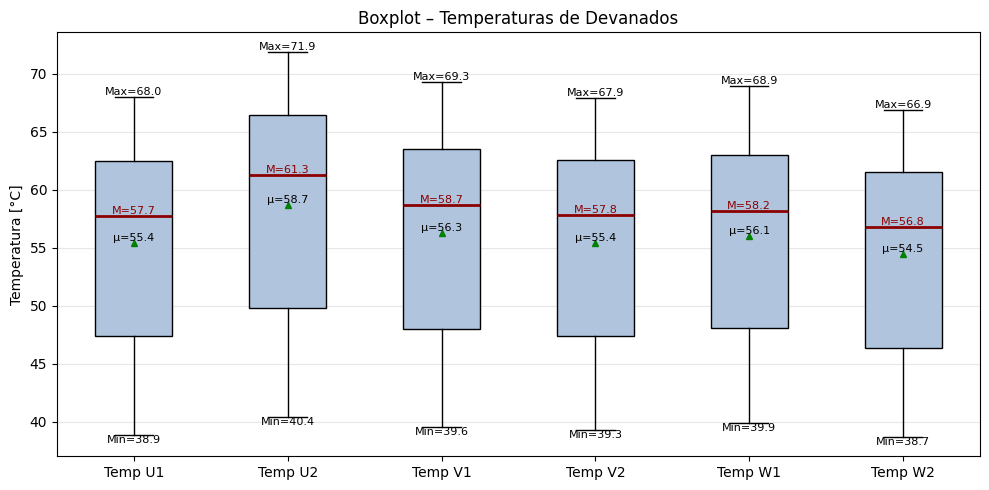

In [ ]:
# Boxplot
boxplot_grupo(
    data_trend,
    temp_devanados,
    temp_devanados_labels,
    "Temperaturas de Devanados",
    "Temperatura [°C]"
)

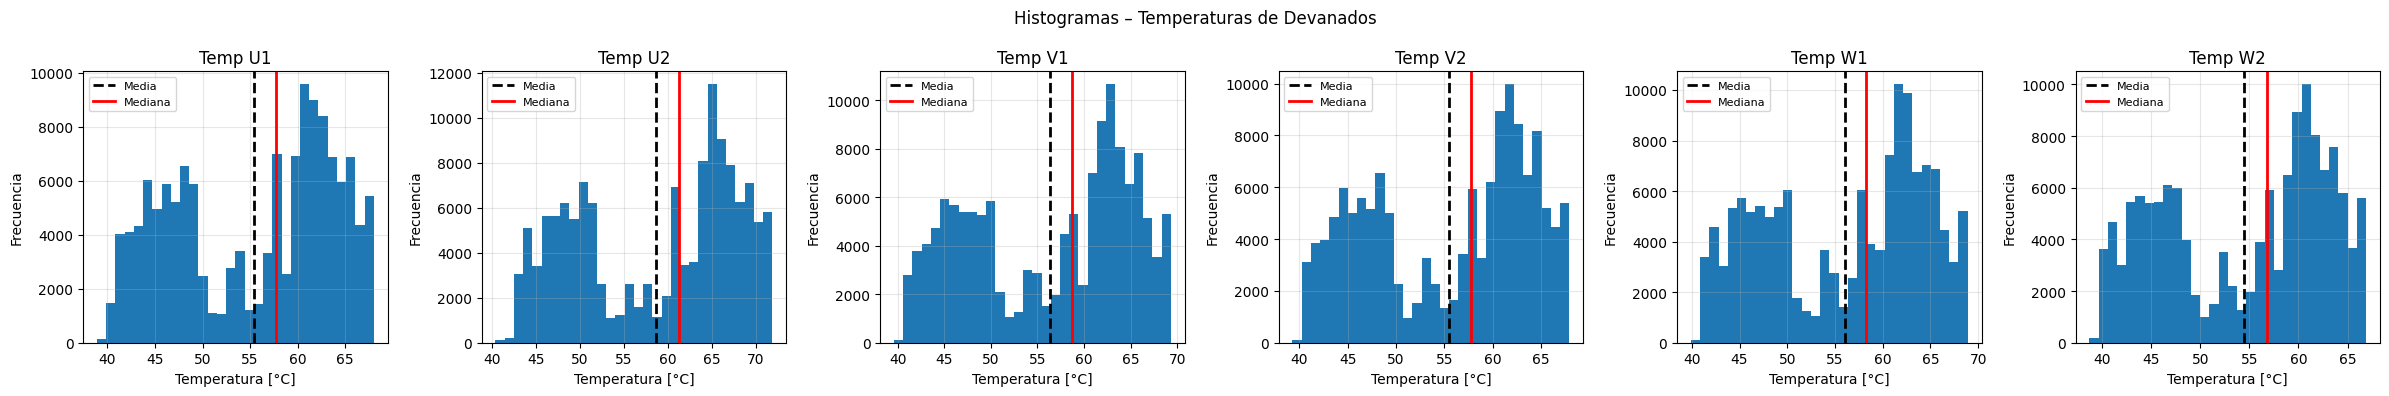

In [ ]:
# Histograma
histogramas_grupo(
    data_trend,
    temp_devanados,
    temp_devanados_labels,
    "Temperaturas de Devanados",
    "Temperatura [°C]"
)

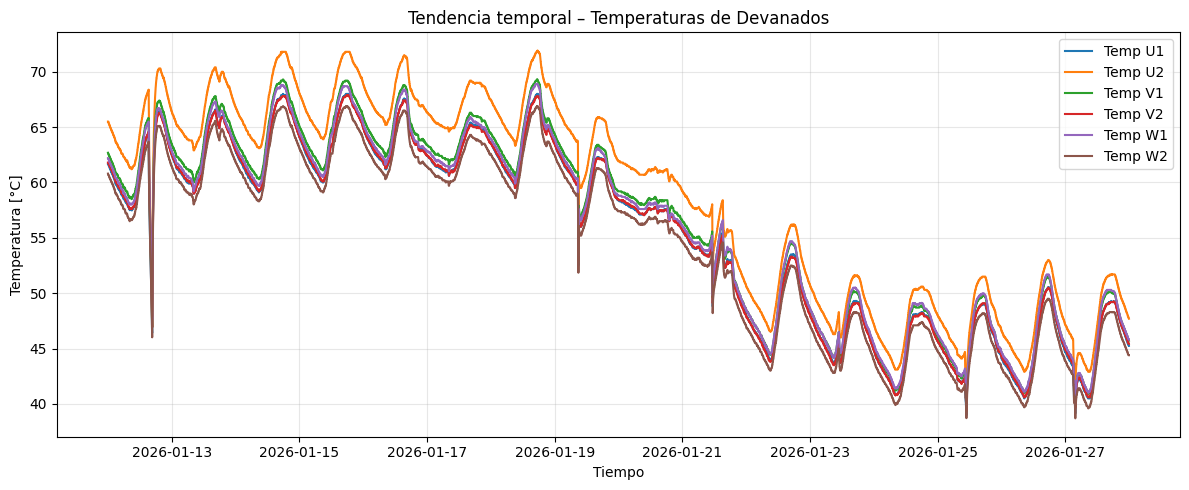

In [ ]:
# Tendencia en el tiempo
tendencia_grupo_simple(
    data_trend,
    temp_devanados,
    temp_devanados_labels,
    "Temperaturas de Devanados",
    "Temperatura [°C]"
)

In [ ]:
# Temperaturas de aire - Grupo 2
temp_aire = [
    'G1-TEMPERATURA AIRE CALIENTE ValueY',
    'G1-TEMPERATURA AIRE FRIO ValueY'
]
temp_aire_labels = ['Temp Aire Caliente', 'Temp Aire Frio' ]

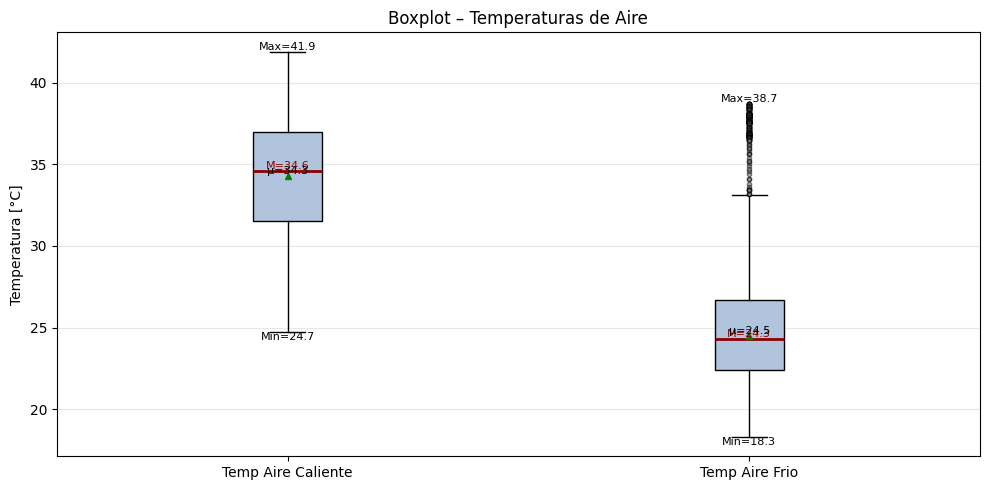

In [ ]:
# Boxplot
boxplot_grupo(
    data_trend,
    temp_aire,
    temp_aire_labels,
    "Temperaturas de Aire",
    "Temperatura [°C]"
)

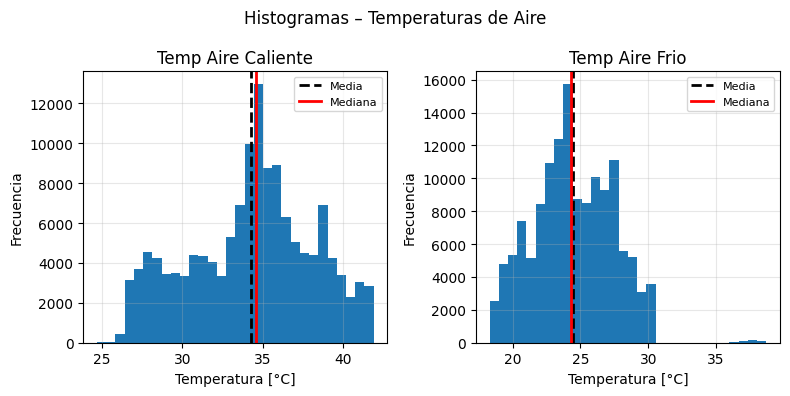

In [ ]:
# Histograma
histogramas_grupo(
    data_trend,
    temp_aire,
    temp_aire_labels,
    "Temperaturas de Aire",
    "Temperatura [°C]"
)

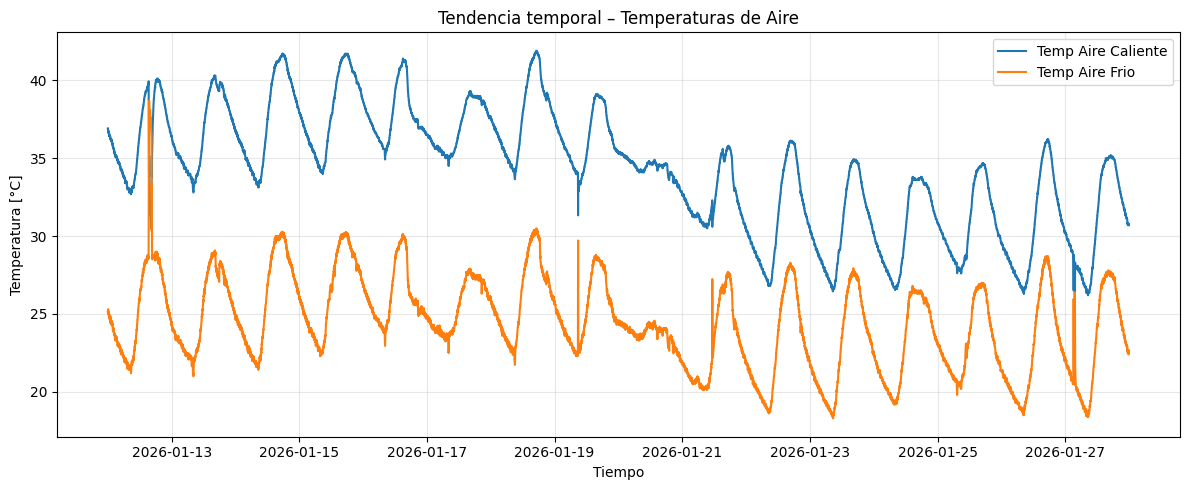

In [ ]:
# Tendencia en el tiempo
tendencia_grupo_simple(
    data_trend,
    temp_aire,
    temp_aire_labels,
    "Temperaturas de Aire",
    "Temperatura [°C]"
)

In [ ]:
# Temperaturas de cojinetes - Grupo 3
temp_cojinete = [
    'G1-TEMPERATURA COJINETE LA ValueY',
    'G1-TEMPERATURA COJINETE RADIAL LO ValueY'
]
temp_cojinete_labels = ['Temp Cojinetes LA', 'Temp Cojinetes Radial LO']

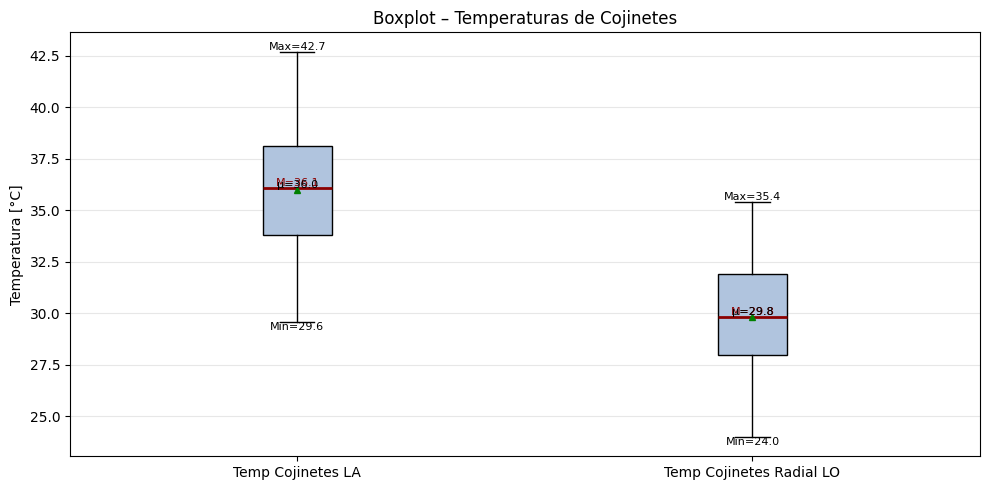

In [ ]:
# Boxplot
boxplot_grupo(
    data_trend,
    temp_cojinete,
    temp_cojinete_labels,
    "Temperaturas de Cojinetes",
    "Temperatura [°C]"
)

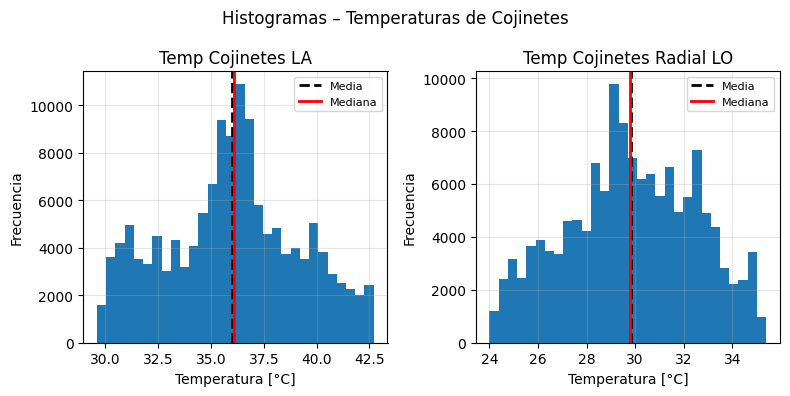

In [ ]:
# Histograma
histogramas_grupo(
    data_trend,
    temp_cojinete,
    temp_cojinete_labels,
    "Temperaturas de Cojinetes",
    "Temperatura [°C]"
)

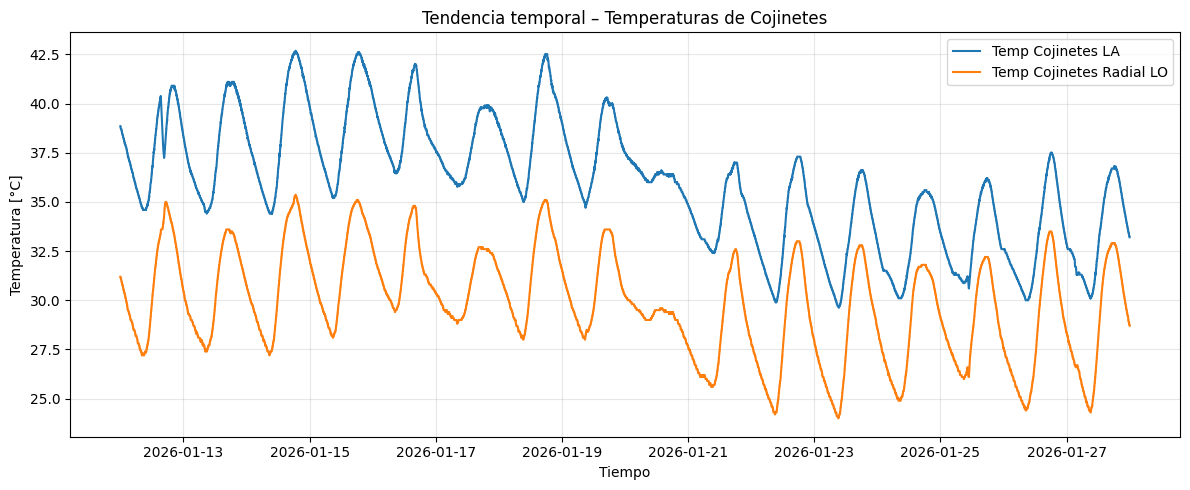

In [ ]:
# Tendencia en el tiempo
tendencia_grupo_simple(
    data_trend,
    temp_cojinete,
    temp_cojinete_labels,
    "Temperaturas de Cojinetes",
    "Temperatura [°C]"
)

In [ ]:
# Temperaturas de rodamientos - Grupo 4
temp_rodamiento = [
   'G1-TEMPERATURA RODAMIENTO GUIA ValueY',
    'G1-TEMPERATURA RODAMIENTO EMPUJE ValueY'
]
temp_rodamiento_labels =  ['Temp Rodamiento Guia', 'Temp Rodamiento Empuje']

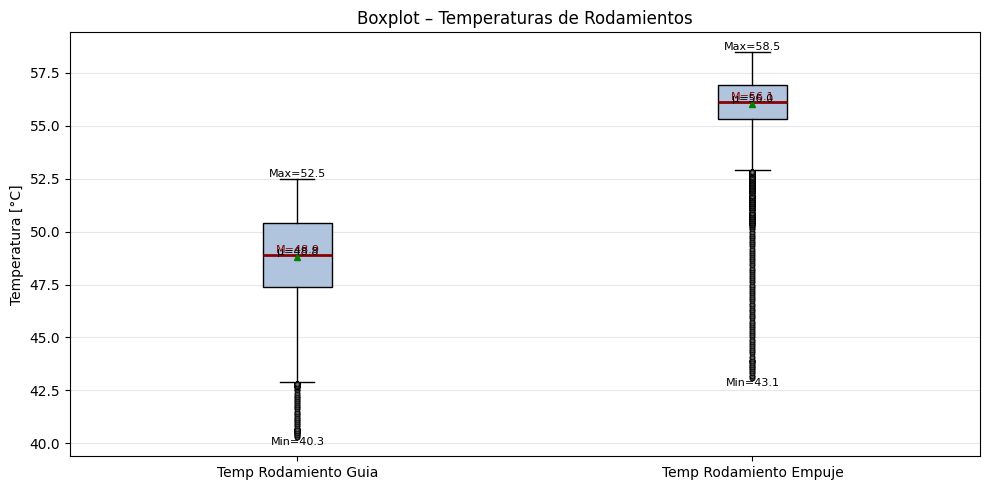

In [ ]:
# Boxplot
boxplot_grupo(
    data_trend,
    temp_rodamiento,
    temp_rodamiento_labels,
    "Temperaturas de Rodamientos",
    "Temperatura [°C]"
)

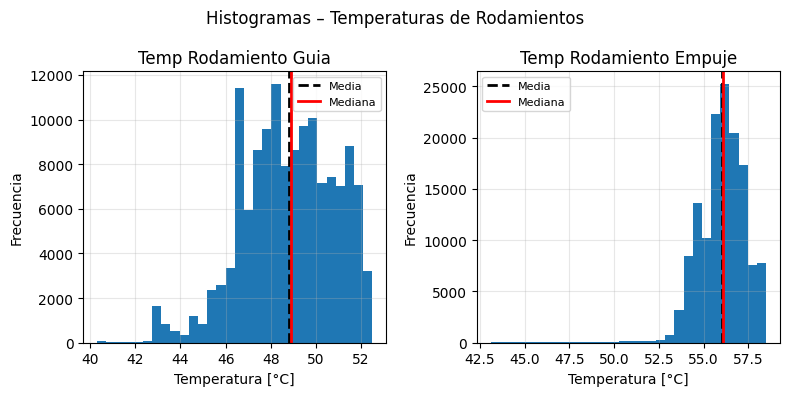

In [ ]:
# Histograma
histogramas_grupo(
    data_trend,
    temp_rodamiento,
    temp_rodamiento_labels,
    "Temperaturas de Rodamientos",
    "Temperatura [°C]"
)

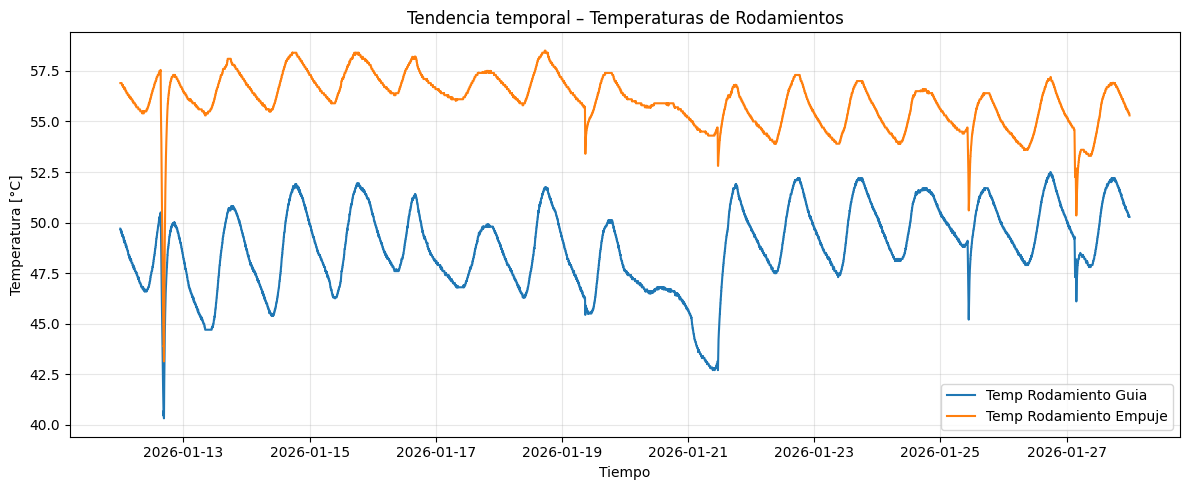

In [ ]:
# Tendencia en el tiempo
tendencia_grupo_simple(
    data_trend,
    temp_rodamiento,
    temp_rodamiento_labels,
    "Temperaturas de Rodamientos",
    "Temperatura [°C]"
)

In [ ]:
# Temperaturas de aceite - Grupo 5
temp_aceite = [
    'G1-TEMPERATURA ACEITE GL ValueY',
    'G1-TEMPERATURA ACEITE RODAMIENTO EMPUJE ValueY'
]
temp_aceite_labels = ['Temp Aceite GL', 'Temp Aceite Rodamiento Empuje']

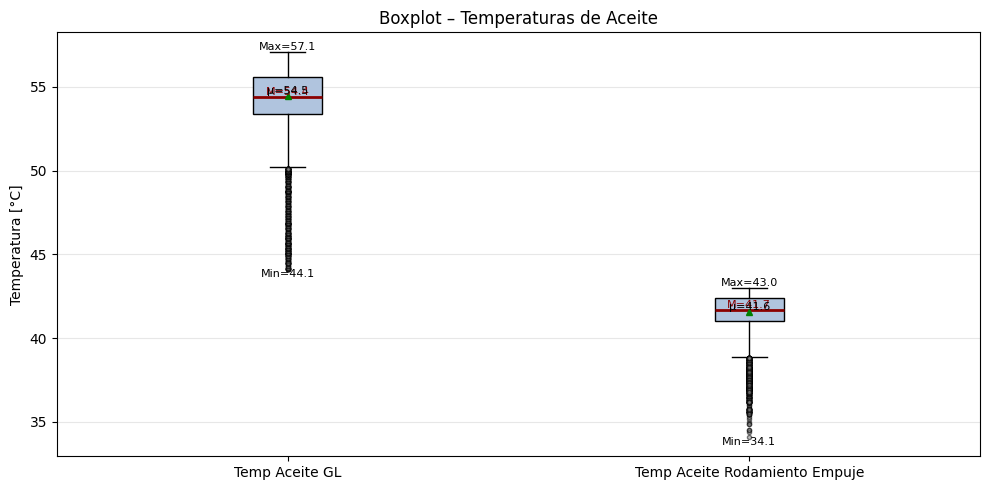

In [ ]:
# Boxplot
boxplot_grupo(
    data_trend,
    temp_aceite,
    temp_aceite_labels,
    "Temperaturas de Aceite",
    "Temperatura [°C]"
)

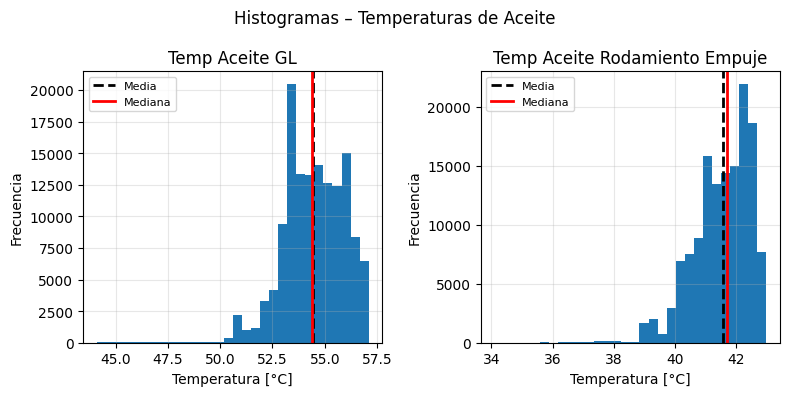

In [ ]:
# Histograma
histogramas_grupo(
    data_trend,
    temp_aceite,
    temp_aceite_labels,
    "Temperaturas de Aceite",
    "Temperatura [°C]"
)

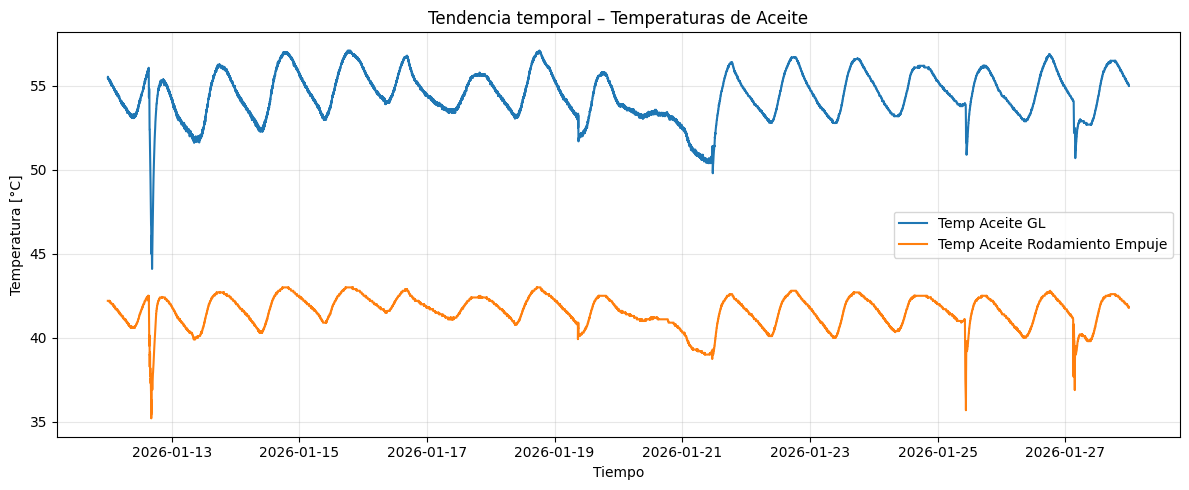

In [ ]:
# Tendencia en el tiempo
tendencia_grupo_simple(
    data_trend,
    temp_aceite,
    temp_aceite_labels,
    "Temperaturas de Aceite",
    "Temperatura [°C]"
)

In [ ]:
# Vibraciones - Grupo 6
vibraciones = [
    'G1-VIBRACION  COJINETE LA ValueY',
    'G1-VIBRACION  COJINETE LO ValueY'
]
vibraciones_labels = ['Vibracion Cojinetes LA', 'Vibracion Cojinetes LO']

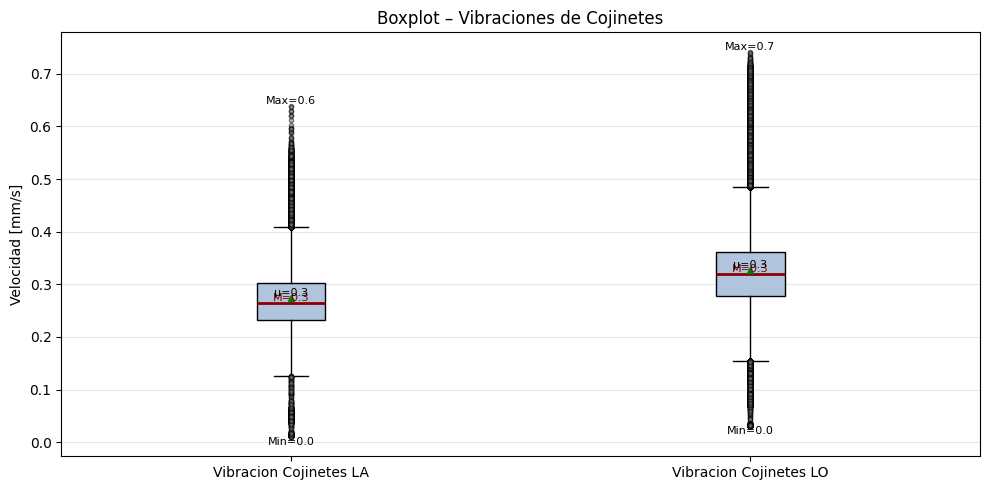

In [ ]:
# Boxplot
boxplot_grupo(
    data_trend,
    vibraciones,
    vibraciones_labels,
    "Vibraciones de Cojinetes",
    "Velocidad [mm/s]"
)

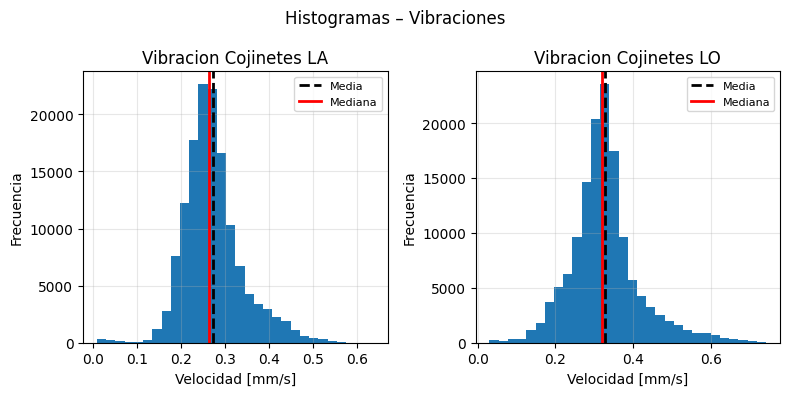

In [ ]:
# Histograma
histogramas_grupo(
    data_trend,
    vibraciones,
    vibraciones_labels,
    "Vibraciones",
    "Velocidad [mm/s]"
)

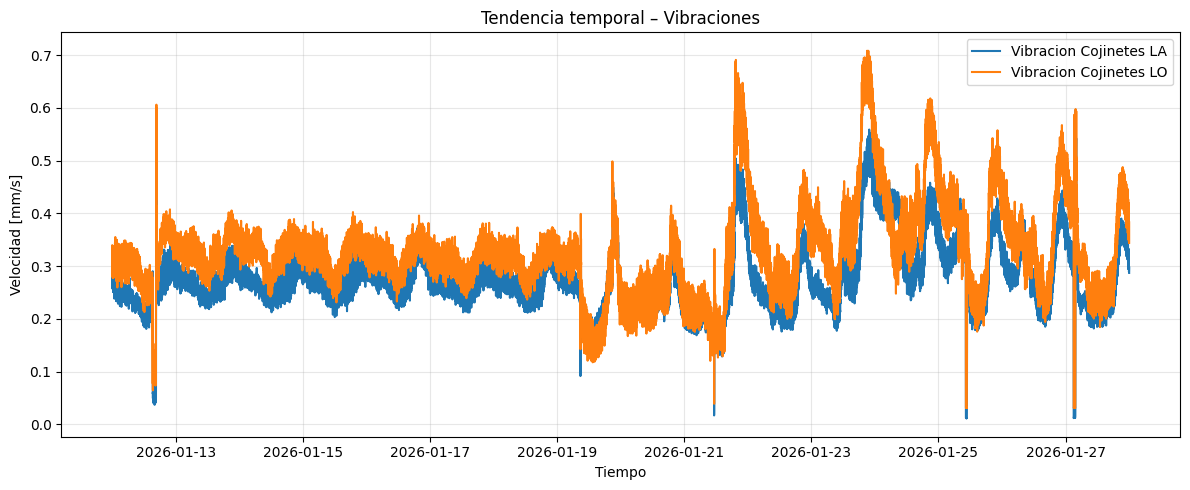

In [ ]:
# Tendencia en el tiempo
tendencia_grupo_simple(
    data_trend,
    vibraciones,
    vibraciones_labels,
    "Vibraciones",
    "Velocidad [mm/s]"
)

# Resumen de Gráficas

In [ ]:
grupos = [
    (temp_devanados, temp_devanados_labels, "Temperaturas de Devanados", "Temperatura [°C]"),
    (temp_aire, temp_aire_labels, "Temperaturas de Aire", "Temperatura [°C]"),
    (temp_cojinete, temp_cojinete_labels, "Temperaturas de Cojinetes", "Temperatura [°C]"),
    (temp_rodamiento, temp_rodamiento_labels, "Temperaturas de Rodamientos", "Temperatura [°C]"),
    (temp_aceite, temp_aceite_labels, "Temperaturas de Aceite", "Temperatura [°C]"),
    (vibraciones, vibraciones_labels, "Vibraciones", "Velocidad [mm/s]")
]

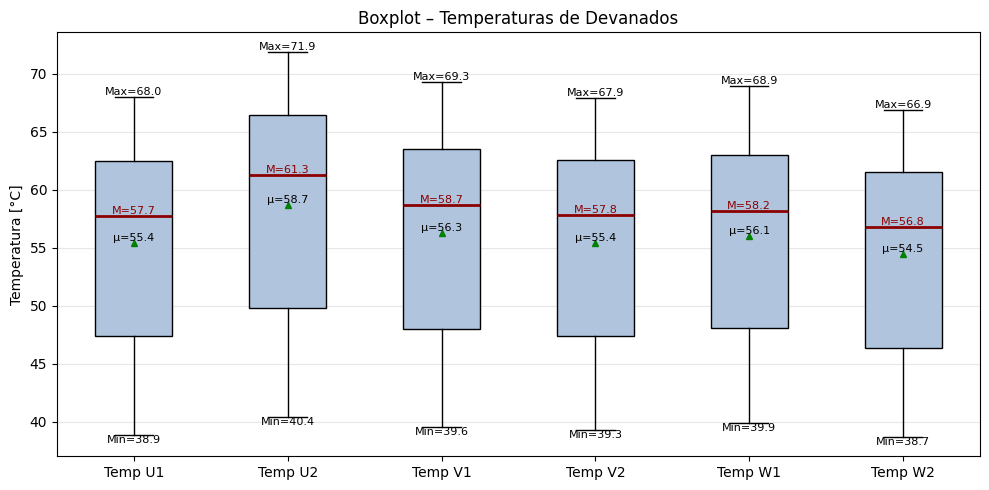

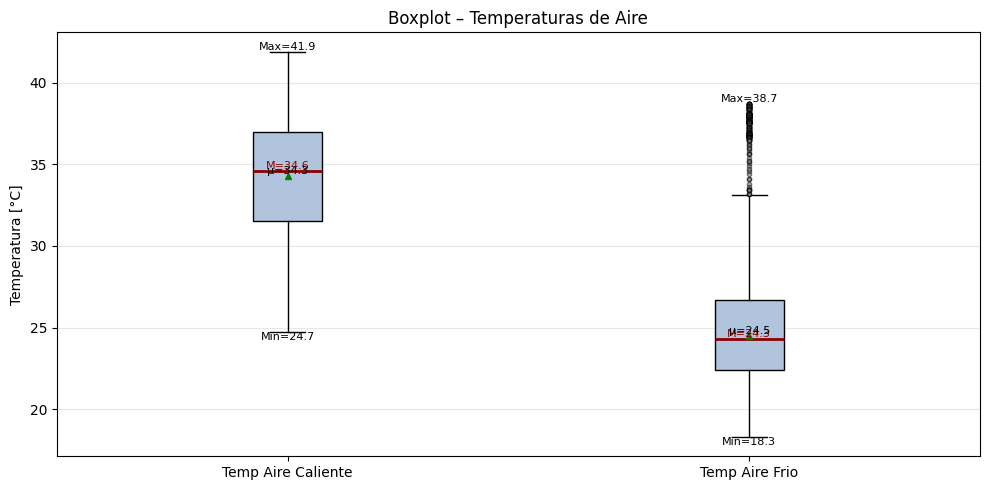

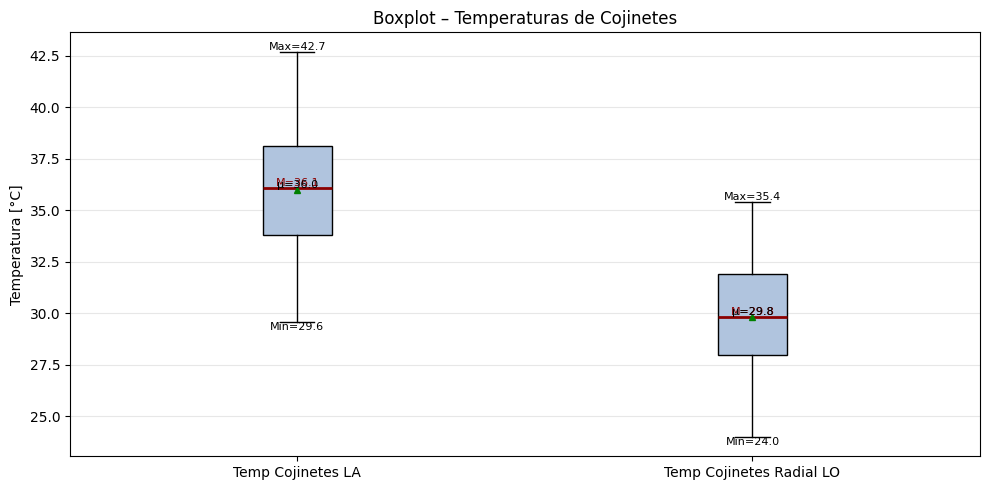

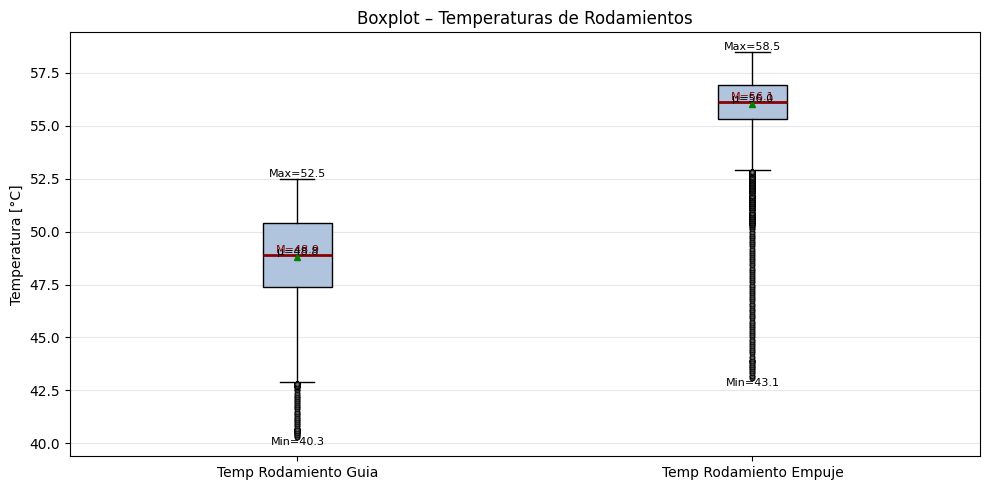

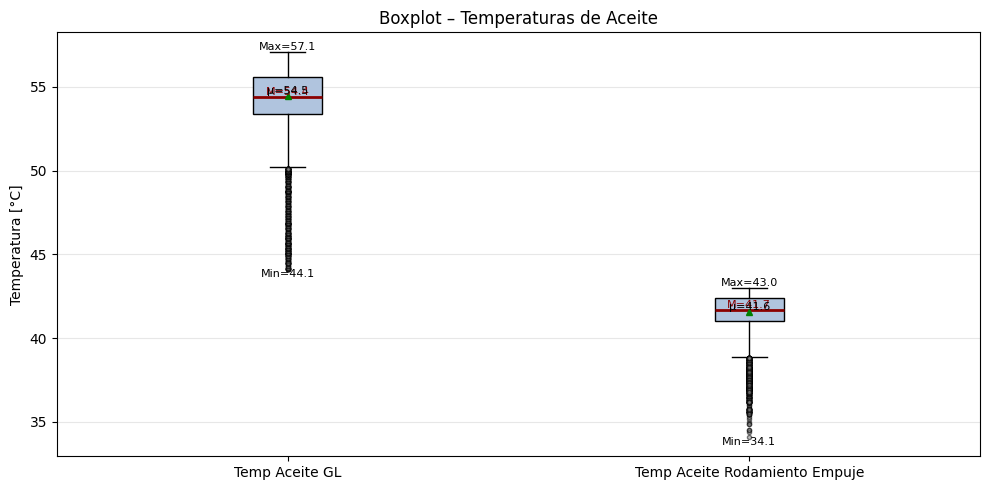

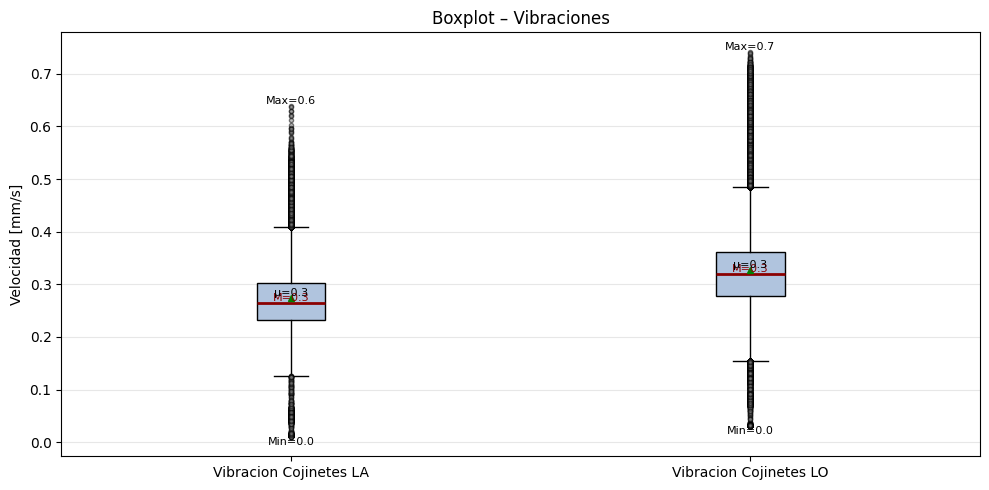

In [ ]:
for cols, labels, titulo, ylabel in grupos:
    boxplot_grupo(data_trend, cols, labels, titulo, ylabel)
    print("")

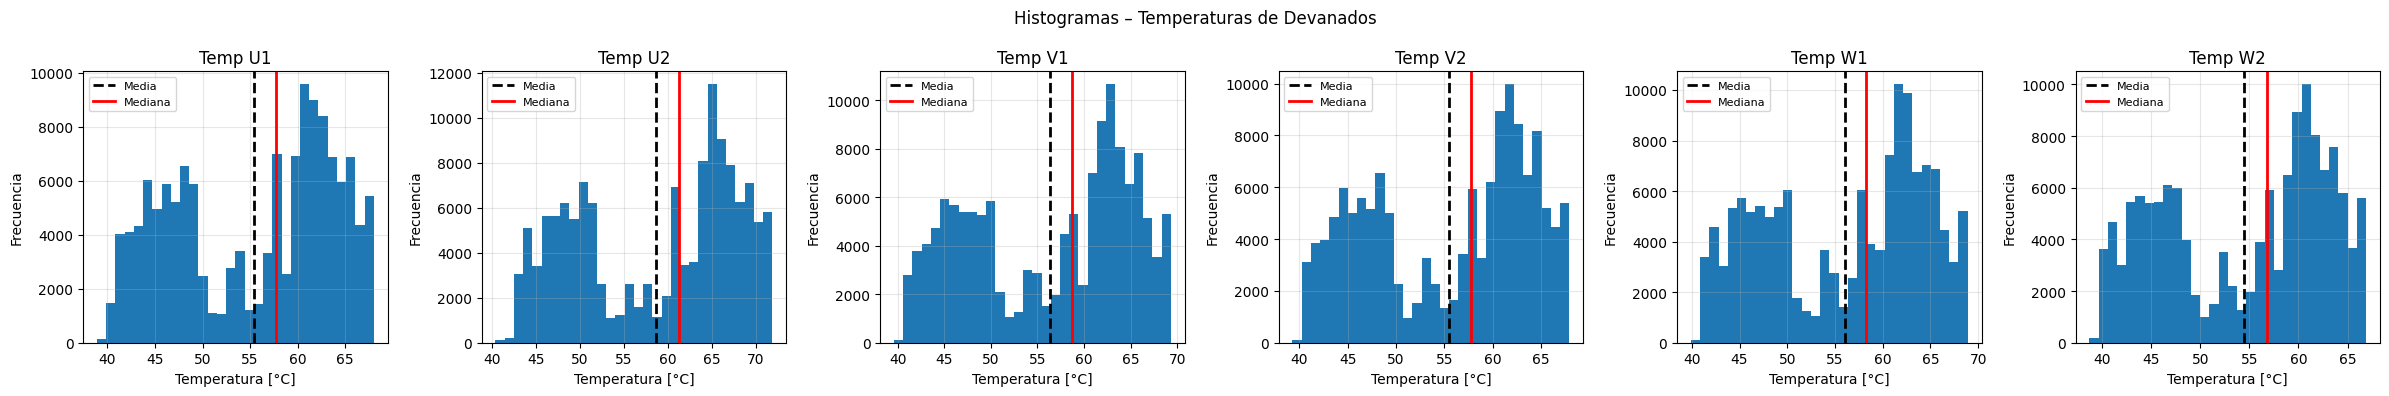

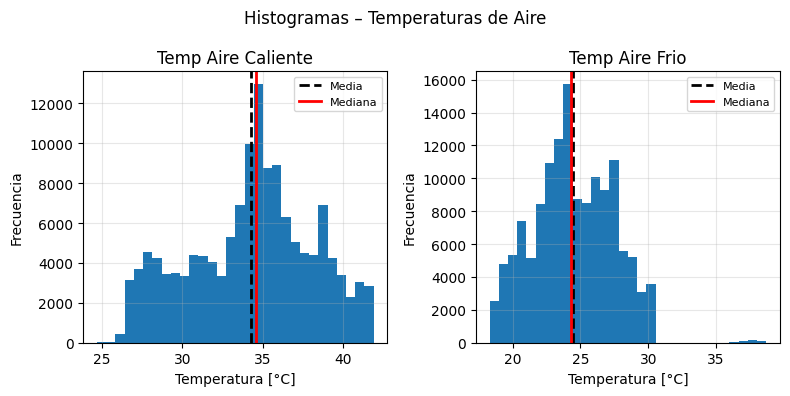

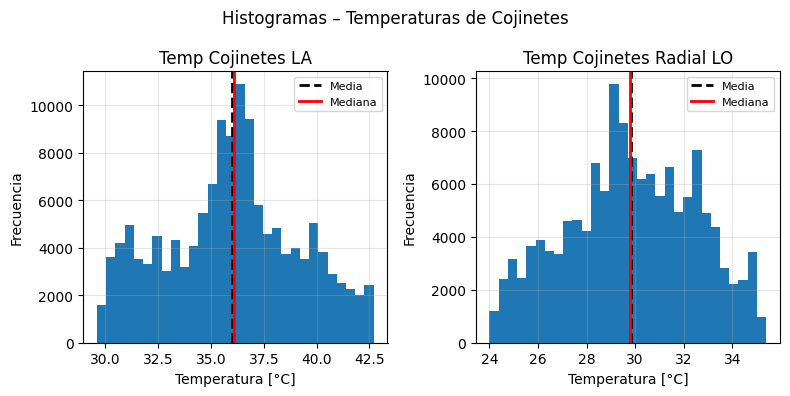

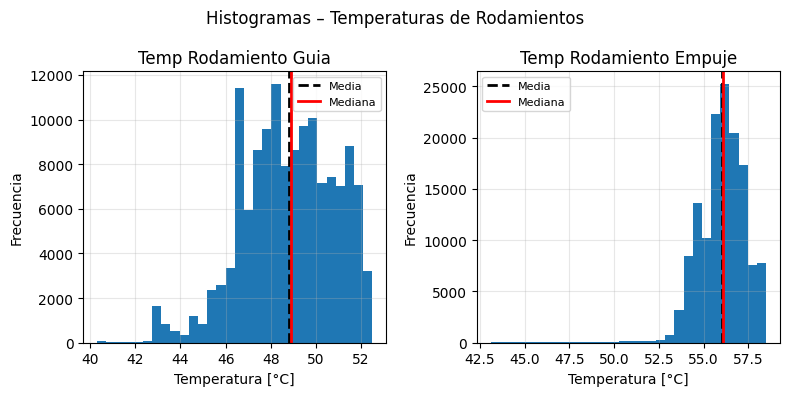

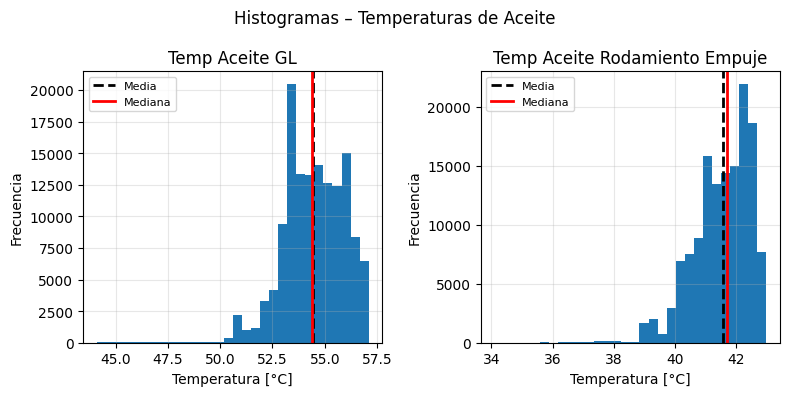

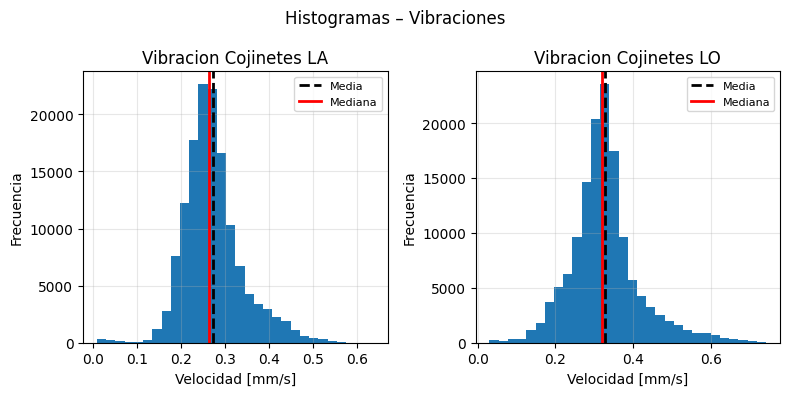

In [ ]:
for cols, labels, titulo, xlabel in grupos:
    histogramas_grupo(data_trend, cols, labels, titulo, xlabel)
    print("")

In [ ]:
# Análisis univariante
# Se realizó un análisis estadístico univariante de las principales variables térmicas y mecánicas del conjunto turbina–generador G1 mediante diagramas de caja e histogramas,
# con el objetivo de evaluar la distribución, dispersión, valores extremos y comportamiento operativo de cada subsistema.

#Temperaturas de devanados
# Las temperaturas de los devanados U1, U2, V1, V2, W1 y W2 presentan distribuciones similares y rangos de operación homogéneos, con medianas entre 57 °C y 61 °C.
# No se observan diferencias significativas entre fases, lo que sugiere una carga térmica balanceada del generador.

# Temperaturas de aire (enfriamiento)
# El aire caliente muestra valores medios cercanos a 35 °C, mientras que el aire frío se mantiene alrededor de 24–25 °C.
# La separación térmica entre ambas mediciones confirma el correcto funcionamiento del sistema de ventilación/enfriamiento. Se observan algunos valores altos aislados en el aire frío, posiblemente asociados a transitorios de carga o variaciones ambientales.

# Temperaturas de cojinetes
# Los cojinetes presentan temperaturas estables, con medianas aproximadas de 36 °C (lado LA) y 30 °C (lado radial LO).
# La baja dispersión observada indica condiciones adecuadas de lubricación y fricción controlada. No se identifican incrementos abruptos que sugieran desgaste o problemas mecánicos.

# Temperaturas de rodamientos
# El rodamiento guía opera alrededor de 49 °C y el rodamiento de empuje cerca de 56 °C.
# Las distribuciones son estrechas y consistentes, lo que evidencia estabilidad térmica. La ausencia de colas largas o outliers severos sugiere un funcionamiento normal del sistema mecánico.

# Temperaturas de aceite
# Las temperaturas del aceite de lubricación se mantienen en rangos esperados (≈54–55 °C para aceite general y ≈41–42 °C en rodamiento de empuje).
# La baja variabilidad indica una adecuada disipación de calor y correcto desempeño del sistema de lubricación.

# Vibraciones de cojinetes
# Las vibraciones presentan valores bajos y concentrados (≈0.25–0.35 mm/s), con distribuciones unimodales y ligera asimetría positiva.
# Los niveles registrados son compatibles con operación estable y no evidencian desbalance, desalineación ni defectos mecánicos significativos.

# Conclusión general
# En conjunto, las variables analizadas muestran distribuciones estables, sin presencia de valores atípicos críticos ni comportamientos anómalos persistentes.
# Los rangos térmicos y niveles de vibración se encuentran dentro de condiciones normales de operación, lo que sugiere un funcionamiento adecuado del sistema turbina–generador durante el período evaluado.

# Los datos se consideran consistentes y aptos para continuar con análisis más avanzados, tales como tendencias temporales, correlaciones entre variables y detección de anomalías.


# Análisis bi/multivariante
##### En esta sección se exploran las relaciones entre variables mediante análisis de correlación, tanto en forma cuantitativa (matriz de correlación) como gráfica (mapa de calor y diagramas de dispersión). Esto permite identificar dependencias lineales, variables redundantes y posibles relaciones físicas entre subsistemas del equipo.


In [ ]:
# 1. Matriz de correlación (numéricas)
num_cols = data_trend.select_dtypes(include='float64').columns

corr = (
    data_trend[num_cols]
    .corr()
    .round(2)          # menos decimales = más legible
)

corr

,G1-TEMPERATURA DEVANADO U1 ValueY,G1-TEMPERATURA DEVANADO U2 ValueY,G1-TEMPERATURA DEVANADO V1 ValueY,G1-TEMPERATURA DEVANADO V2 ValueY,G1-TEMPERATURA DEVANADO W1 ValueY,G1-TEMPERATURA DEVANADO W2 ValueY,G1-TEMPERATURA AIRE CALIENTE ValueY,G1-TEMPERATURA AIRE FRIO ValueY,G1-TEMPERATURA COJINETE LA ValueY,G1-TEMPERATURA RODAMIENTO EMPUJE ValueY,G1-TEMPERATURA COJINETE RADIAL LO ValueY,G1-TEMPERATURA RODAMIENTO GUIA ValueY,G1-VIBRACION COJINETE LA ValueY,G1-VIBRACION COJINETE LO ValueY,G1-TEMPERATURA ACEITE GL ValueY,G1-TEMPERATURA ACEITE RODAMIENTO EMPUJE ValueY
G1-TEMPERATURA DEVANADO U1 ValueY,1.00,1.00,1.00,1.00,1.00,1.00,0.92,0.63,0.89,0.73,0.66,-0.11,-0.21,-0.26,0.20,0.37
G1-TEMPERATURA DEVANADO U2 ValueY,1.00,1.00,1.00,1.00,1.00,1.00,0.91,0.61,0.88,0.72,0.64,-0.13,-0.21,-0.26,0.18,0.36
G1-TEMPERATURA DEVANADO V1 ValueY,1.00,1.00,1.00,1.00,1.00,1.00,0.92,0.63,0.89,0.72,0.66,-0.11,-0.22,-0.27,0.20,0.37
G1-TEMPERATURA DEVANADO V2 ValueY,1.00,1.00,1.00,1.00,1.00,1.00,0.91,0.63,0.89,0.72,0.65,-0.11,-0.21,-0.26,0.19,0.37
G1-TEMPERATURA DEVANADO W1 ValueY,1.00,1.00,1.00,1.00,1.00,1.00,0.92,0.64,0.89,0.73,0.67,-0.10,-0.23,-0.27,0.21,0.38
G1-TEMPERATURA DEVANADO W2 ValueY,1.00,1.00,1.00,1.00,1.00,1.00,0.92,0.63,0.89,0.72,0.65,-0.12,-0.22,-0.27,0.19,0.37
G1-TEMPERATURA AIRE CALIENTE ValueY,0.92,0.91,0.92,0.91,0.92,0.92,1.00,0.86,0.97,0.85,0.89,0.22,-0.16,-0.18,0.48,0.62
G1-TEMPERATURA AIRE FRIO ValueY,0.63,0.61,0.63,0.63,0.64,0.63,0.86,1.00,0.85,0.71,0.95,0.47,-0.15,-0.14,0.61,0.67
G1-TEMPERATURA COJINETE LA ValueY,0.89,0.88,0.89,0.89,0.89,0.89,0.97,0.85,1.00,0.83,0.91,0.29,-0.08,-0.11,0.54,0.66
G1-TEMPERATURA RODAMIENTO EMPUJE ValueY,0.73,0.72,0.72,0.72,0.73,0.72,0.85,0.71,0.83,1.00,0.80,0.49,0.05,0.04,0.76,0.85


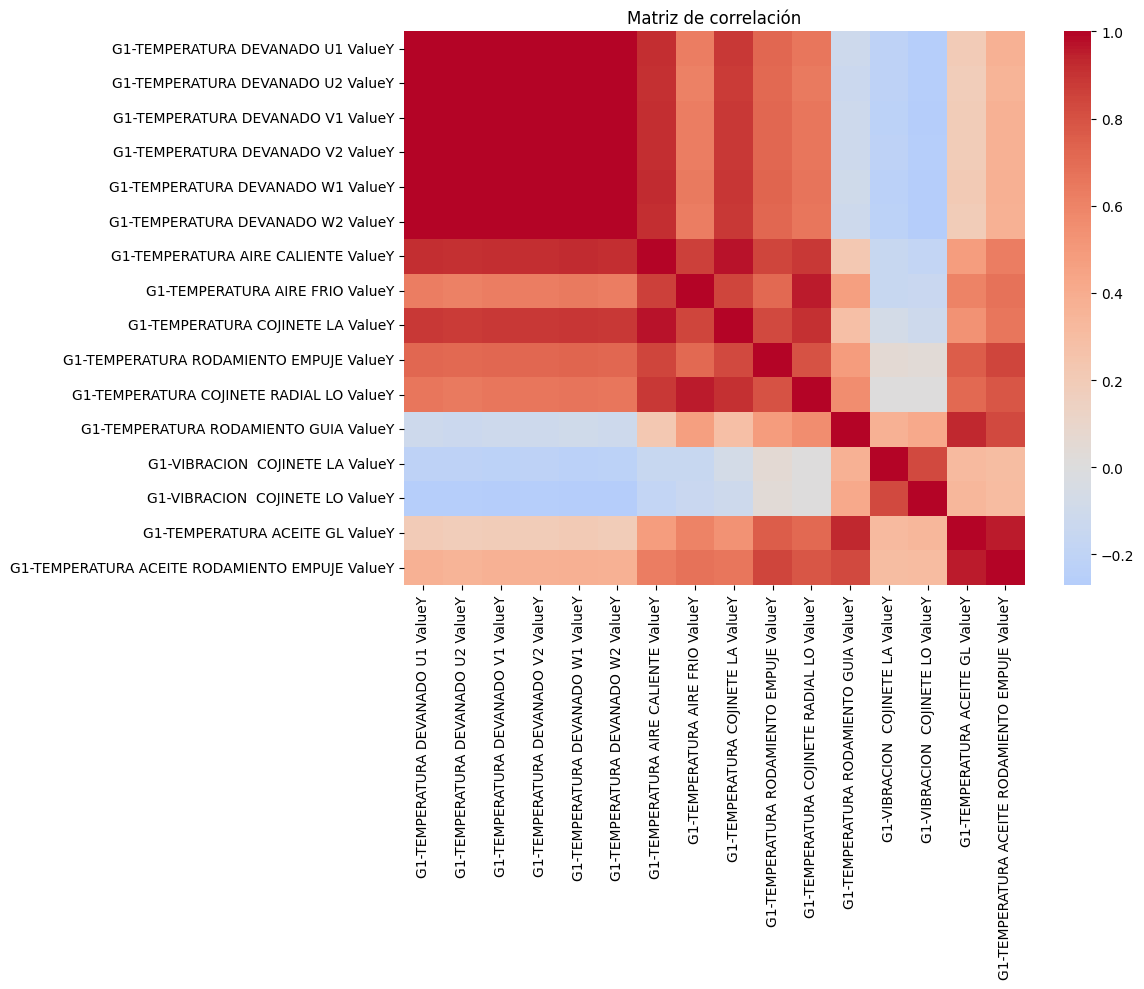

In [ ]:
# Mapeo
num_cols = data_trend.select_dtypes(include='float64').columns
corr = data_trend[num_cols].corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap='coolwarm',     # mapa de calor rojo-azul
    center=0,            # 0 blanco
    annot=False          # sin números (más limpio)
)

plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

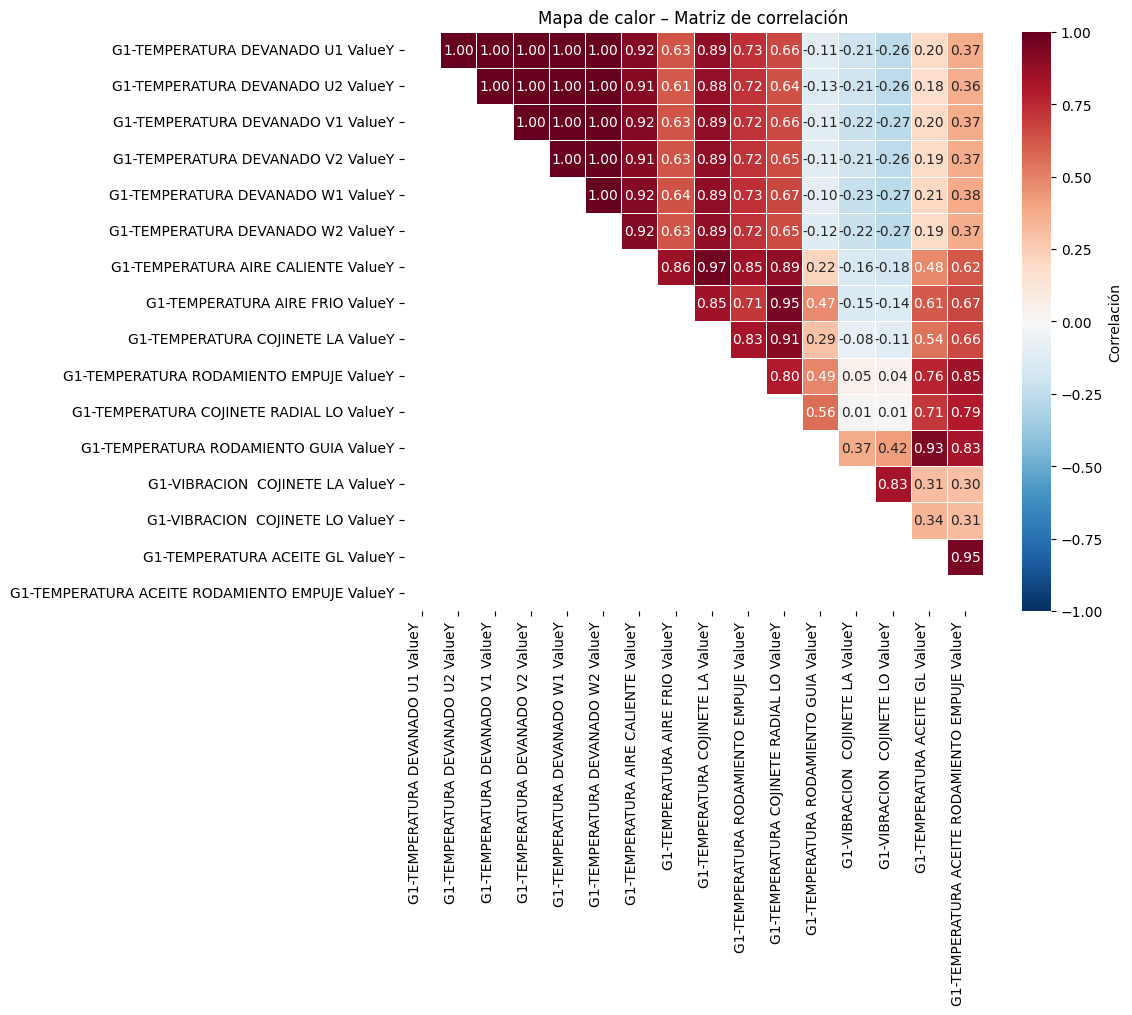

In [ ]:
corr = data_trend[num_cols].corr().round(2)
mask = np.tril(np.ones_like(corr, dtype=bool))  # ocultar mitad inferior
plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    mask=mask,
    cmap='RdBu_r',     # mejor contraste para correlación
    vmin=-1, vmax=1,
    center=0,
    annot=True,        # muestra números
    fmt='.2f',
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Correlación'}
)

plt.title("Mapa de calor – Matriz de correlación")
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Análisis de correlación

# El mapa de calor de correlación muestra relaciones lineales claras entre variables del mismo subsistema.
# Se observa una correlación muy alta (≈ 0.99–1.00) entre las temperaturas de los devanados, lo cual es consistente con un comportamiento térmico homogéneo del generador
# y una distribución equilibrada de carga entre fases.

# Las variables térmicas de cojinetes, rodamientos y aceite presentan correlaciones moderadas-altas (≈ 0.6–0.9), indicando acoplamiento térmico entre los componentes mecánicos y el sistema de lubricación.
# Las vibraciones muestran correlaciones bajas o ligeramente negativas respecto a las temperaturas, lo que sugiere que el comportamiento mecánico
# es relativamente independiente del régimen térmico durante el período analizado.

# En general, no se observan correlaciones anómalas inesperadas, y los patrones detectados son coherentes con la física del sistema turbina–generador.


# Preprocesamiento

##### En esta etapa se aplican técnicas de limpieza y preparación de datos con el objetivo de garantizar la calidad y confiabilidad de la información antes de realizar análisis avanzados o modelado.

Se abordan los siguientes aspectos:

• Manejo de valores faltantes  
• Detección y tratamiento de valores atípicos  
• Revisión de cardinalidad en variables categóricas (si aplica)

Dado que el conjunto proviene de un sistema SCADA, la mayoría de las variables son numéricas continuas, por lo que el enfoque principal se centra en consistencia temporal y eliminación de mediciones anómalas.


In [ ]:
missing = data_trend.isna().sum()

missing[missing > 0]

,0


In [ ]:
# Preprocesamiento

# En esta etapa se evalúan estrategias de limpieza y preparación de datos con el objetivo de garantizar su calidad antes de realizar análisis exploratorios y posteriores tareas de modelado.

# Valores faltantes
# Se verificó la presencia de valores nulos en el conjunto de datos, no identificándose registros faltantes en las variables numéricas.
# Por lo tanto, no fue necesario aplicar técnicas de imputación o interpolación.

# Valores atípicos
# En aplicaciones industriales y sistemas SCADA, los valores extremos no necesariamente representan errores de medición, sino que pueden corresponder a eventos operativos relevantes,
# tales como transitorios, sobrecargas, variaciones de régimen o posibles condiciones de falla.
# Dado que el propósito del presente proyecto es monitorear el comportamiento del equipo y detectar desviaciones respecto a los rangos operativos establecidos por el fabricante,
# los valores atípicos constituyen información de interés diagnóstico.
#Por esta razón, no se eliminaron ni recortaron valores extremos.
#Estos registros se conservaron íntegramente para su análisis posterior, ya que pueden ser indicativos de anomalías o degradación del sistema.

# Cardinalidad
# El conjunto de datos está compuesto principalmente por variables numéricas continuas provenientes de sensores.
# No se identificaron variables categóricas de alta cardinalidad que requieran codificación o reducción de niveles, por lo que no fue necesario aplicar técnicas adicionales de tratamiento.

# Conclusión del preprocesamiento
# El dataset presenta consistencia, ausencia de valores faltantes y conservación intencional de mediciones extremas.
#Por lo tanto, se considera adecuado para análisis estadístico, evaluación de tendencias y detección de anomalías en etapas posteriores.

# Conclusiones

A partir del análisis exploratorio de datos del sistema turbina–generador, se obtuvieron las siguientes observaciones relevantes:

## Calidad y estructura del dataset
El conjunto de datos presenta consistencia estructural, con un total de 138,240 registros y variables mayoritariamente numéricas continuas provenientes de sensores del sistema SCADA. No se identificaron valores faltantes ni registros duplicados, lo que garantiza integridad temporal y confiabilidad en las mediciones.

## Comportamiento univariante
Las distribuciones de temperaturas, vibraciones y variables mecánicas muestran rangos de operación estables y coherentes con el comportamiento esperado de cada subsistema. Los boxplots e histogramas evidencian baja dispersión y ausencia de patrones anómalos persistentes.

Las temperaturas de devanados presentan alta similitud entre fases, lo que sugiere una carga térmica balanceada del generador. Las temperaturas de cojinetes, rodamientos y aceite se mantienen dentro de márgenes normales de operación, indicando un adecuado funcionamiento de los sistemas de enfriamiento y lubricación. Las vibraciones registran niveles bajos, compatibles con una condición mecánica saludable.

## Tendencias temporales
Las series de tiempo muestran estabilidad operativa durante el periodo analizado, sin incrementos sostenidos ni derivas térmicas significativas. Las variaciones observadas corresponden principalmente a cambios de régimen o condiciones normales de operación.

## Relaciones entre variables
El análisis de correlación evidenció:

- Alta correlación entre temperaturas de devanados (comportamiento térmico homogéneo).
- Correlaciones moderadas entre temperaturas mecánicas y aceite, asociadas a transferencia de calor entre componentes.
- Baja correlación entre vibraciones y variables térmicas, lo cual indica independencia relativa entre fenómenos mecánicos y térmicos.

Estos resultados son físicamente consistentes con la dinámica esperada del sistema.

## Preprocesamiento
No fue necesario realizar imputación de datos faltantes ni eliminación de valores extremos. Los valores atípicos se conservaron intencionalmente, ya que en sistemas industriales pueden representar eventos operativos críticos o condiciones de falla, siendo información valiosa para análisis de condición y mantenimiento predictivo.

## Conclusión general
En conjunto, los datos presentan calidad adecuada, estabilidad operativa y coherencia física entre variables. El dataset se considera apto para etapas posteriores de análisis avanzado, tales como detección de anomalías, modelado predictivo, monitoreo de condición o estimación de límites operativos.

El análisis realizado constituye una base sólida para el desarrollo de herramientas de diagnóstico y evaluación del estado de la máquina eléctrica.
